In [19]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor


DATA_FOLDER = "./"

df = pd.read_pickle(DATA_FOLDER + "df_fe_epic_light_best_customers_50c.pickle")
#df = pd.read_pickle(DATA_FOLDER + "df_fe_epic_light_grouped.pickle")
if not "serie_id" in df.columns:
    df["serie_id"] = df["product_id"].astype(str) + "_" + df["customer_id"].astype(str)

product_ids = pd.read_csv(DATA_FOLDER + "product_id_apredecir201912.txt", sep="\t")[
    "product_id"
].tolist()
df["serie_id"] = df["product_id"].astype(str) + "_" + df["customer_id"].astype(str)
df

,product_id,customer_id,fecha,periodo_min_producto,periodo_max_producto,periodo_min_customer,periodo_max_customer,plan_precios_cuidados,cust_request_qty,cust_request_tn,...,cust_request_qty_product_id_vendidas,cust_request_qty_product_id_vendidas_div,cust_request_qty_customer_id_vendidas,cust_request_qty_customer_id_vendidas_div,tn_customer_vendidas,tn_total_vendidas,tn_customer_weight,tn_product_vendidas,tn_product_weight,serie_id
0,20001,0,2017-01,NaT,NaT,NaT,NaT,NaN,196,94.871902,...,479,0.409186,80580,0.002432,7129.603516,34057.316406,0.209341,934.772217,2.744703e-02,20001_0
1,20001,10001,2017-01,2017-01-01,2019-12-01,2017-01-01,2019-12-01,0.0,11,99.438606,...,479,0.022965,4013,0.002741,2543.899414,34057.316406,0.074695,934.772217,2.744703e-02,20001_10001
2,20001,10002,2017-01,2017-01-01,2019-12-01,2017-01-01,2019-12-01,0.0,17,38.683010,...,479,0.035491,14680,0.001158,3143.644775,34057.316406,0.092305,934.772217,2.744703e-02,20001_10002
3,20001,10003,2017-01,2017-01-01,2019-12-01,2017-01-01,2019-12-01,0.0,17,143.494263,...,479,0.035491,8182,0.002078,2425.989014,34057.316406,0.071233,934.772217,2.744703e-02,20001_10003
4,20001,10004,2017-01,2017-01-01,2019-12-01,2017-01-01,2019-12-01,0.0,9,184.729263,...,479,0.018789,5606,0.001605,1738.918335,34057.316406,0.051059,934.772217,2.744703e-02,20001_10004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1607617,21276,10046,2019-12,2019-03-01,2019-12-01,2017-01-01,2019-12-01,0.0,0,0.000000,...,4,0.000000,65,0.000000,56.943310,26217.066406,0.002172,0.008920,3.402363e-07,21276_10046
1607618,21276,10047,2019-12,2019-03-01,2019-12-01,2017-01-01,2019-12-01,0.0,0,0.000000,...,4,0.000000,135,0.000000,94.281326,26217.066406,0.003596,0.008920,3.402363e-07,21276_10047
1607619,21276,10048,2019-12,2019-03-01,2019-12-01,2017-01-01,2019-12-01,0.0,0,0.000000,...,4,0.000000,246,0.000000,166.782974,26217.066406,0.006362,0.008920,3.402363e-07,21276_10048
1607620,21276,10050,2019-12,2019-03-01,2019-12-01,2017-01-01,2019-12-01,0.0,0,0.000000,...,4,0.000000,80,0.000000,117.360664,26217.066406,0.004476,0.008920,3.402363e-07,21276_10050


In [20]:
series_ids = df["serie_id"].unique().tolist()


In [21]:
# calculo el rolling_mean_12 de tn agrupado por product_id para fallout
df["tn_rolling_mean_12"] = (
    df.groupby("product_id")["tn"].transform(
        lambda x: x.rolling(window=12, min_periods=1).mean()
    )
)
fallback = df[["serie_id", "product_id", "fecha", "tn_rolling_mean_12"]]
fallback

,serie_id,product_id,fecha,tn_rolling_mean_12
0,20001_0,20001,2017-01,94.871902
1,20001_10001,20001,2017-01,97.155254
2,20001_10002,20001,2017-01,76.679523
3,20001_10003,20001,2017-01,93.383208
4,20001_10004,20001,2017-01,111.652419
...,...,...,...,...
1607617,21276_10046,21276,2019-12,0.000000
1607618,21276_10047,21276,2019-12,0.000000
1607619,21276_10048,21276,2019-12,0.000000
1607620,21276_10050,21276,2019-12,0.000000


In [22]:
# creo 11 lags de tn
for i in range(1, 12):
    df[f"tn_{i}"] = df.groupby("serie_id")["tn"].shift(i)
magicos = [ 20002, 20003, 20006, 20010, 20011, 20018, 20019, 20021,
   20026, 20028, 20035, 20039, 20042, 20044, 20045, 20046,  20049,
   20051, 20052, 20053, 20055, 20008, 20001, 20017, 20086, 20180,
   20193, 20320, 20532, 20612, 20637, 20807, 20838
 ]
# train son los productos magicos en 2018-12
#train_index = df[
#    (df["fecha"] == "2018-12-01") & (df["product_id"].isin(magicos))
#].index
#train_df = df.loc[train_index].copy()
train_features = ["tn"] + [f"tn_{i}" for i in range(1, 12)]
df["target"] = df.groupby("serie_id")["tn"].shift(-2)

In [23]:
df.groupby(["fecha", "product_id"])["target"].sum().reset_index().sort_values("target", ascending=False)

,fecha,product_id,target
15953,2018-08,20001,2295.198242
26828,2019-08,20002,1979.536377
5645,2017-08,20003,1958.598389
9923,2018-01,20001,1856.835327
16810,2018-09,20001,1813.015137
...,...,...,...
31450,2019-12,21137,0.000000
31451,2019-12,21140,0.000000
31452,2019-12,21142,0.000000
31453,2019-12,21144,0.000000


In [24]:
df[train_features].isna().sum().sum()

np.int64(3911343)

In [25]:
train_df_ = df[(df["fecha"] == "2018-12")]
# ordeno tn de mayor a menor
train_df = train_df_.sort_values("tn", ascending=False)
series_ids_sorted = train_df["serie_id"].unique().tolist()
# las separo en cuantiles de 10, y armo una serie tal que el orden sea 1 del primer cuantil, 2 del segundo, hasta el 10, luego vuelve a 1 del primer cuantil, etc.
total_series = len(series_ids_sorted)
series_ids_ordered = []
for i in range(10):
    # quantil numero i
    quantil = series_ids_sorted[i * (total_series // 10):(i + 1) * (total_series // 10)]
    series_ids_ordered.append(quantil)
series_ids_ordered_plain = []
for quantiles in zip(*series_ids_ordered):
    series_ids_ordered_plain.extend(quantiles)
series_ids_ordered_plain

['20002_10001',
 '20379_10003',
 '20366_10011',
 '20488_10015',
 '20999_10025',
 '21001_10043',
 '20828_10041',
 '20318_10019',
 '20159_10047',
 '20586_10033',
 '20001_10001',
 '20853_0',
 '20366_10036',
 '20283_10042',
 '21190_10021',
 '21001_10042',
 '20828_10040',
 '20318_10018',
 '20159_10045',
 '20586_10032',
 '20001_10004',
 '20386_10003',
 '20332_10005',
 '20650_10018',
 '20999_10024',
 '21001_10041',
 '20828_10039',
 '20318_10017',
 '20159_10044',
 '20586_10031',
 '20003_0',
 '20107_10018',
 '20068_10015',
 '20486_10005',
 '20999_10004',
 '21001_10040',
 '20828_10038',
 '20318_10016',
 '20159_10042',
 '20586_10030',
 '20004_0',
 '20168_10018',
 '20524_10009',
 '20848_10011',
 '21036_10029',
 '21001_10039',
 '20828_10037',
 '20318_10015',
 '20159_10040',
 '20586_10029',
 '20015_10002',
 '20284_10005',
 '20697_10003',
 '20609_10021',
 '21190_10014',
 '21001_10038',
 '21212_10023',
 '20318_10014',
 '20158_10050',
 '20586_10028',
 '20002_0',
 '20638_10005',
 '20832_10001',
 '20283_

In [26]:
from sklearn.linear_model import LinearRegression
def test_eval(df, product_ids, train_features, reg):
    eval_df = df[
        (df["fecha"] == "2019-10") & (df["product_id"].isin(product_ids))
    ].copy()
    X_eval = eval_df[train_features].dropna()
    #y_eval = eval_df.loc[X_eval.index, "target"]
    y_pred = reg.predict(X_eval)
    predictions = pd.DataFrame({
        "product_id": eval_df.loc[X_eval.index, "product_id"],
        "customer_id": eval_df.loc[X_eval.index, "customer_id"],
        "tn_pred": y_pred,
        "tn_real": eval_df.loc[X_eval.index, "target"]
    })
    predictions = predictions.groupby("product_id").agg({
        "tn_pred": "sum",
        "tn_real": "sum"
    }).reset_index()
    total_error = (predictions["tn_pred"] - predictions["tn_real"]).abs().sum() / predictions["tn_real"].sum()
    return total_error

magical_series_ids = []
best_reg = None
max_series = 100

best_eval_value = float("inf")
for serie_id in series_ids_ordered_plain:
    # si df[df["serie_id"] == serie_id][train_features] tiene nans ignoro este serie_id
    if df[(df["fecha"] == "2018-12") & (df["serie_id"] == serie_id)][train_features].isnull().any().any():
        print(f"Skipping series {serie_id} due to NaNs in training features")
        continue
    magical_series_ids.append(serie_id)
    train_index = df[(df["fecha"] == "2018-12") & df["serie_id"].isin(magical_series_ids)].index
    train_df = df.loc[train_index].copy()
    X_train = train_df[train_features].dropna()
    y_train = train_df.loc[X_train.index, "target"]
    if y_train.isnull().any():
        print(f"Skipping series {serie_id} due to NaNs in target")
        magical_series_ids.remove(serie_id)
        continue
    reg = LinearRegression()
    reg.fit(X_train, y_train)
    error = test_eval(df, product_ids, train_features, reg)
    if error < best_eval_value:
        best_eval_value = error
        best_reg = reg
        print(f"New best model for series {serie_id} with error: {error:.4f}")
    else:
        magical_series_ids.remove(serie_id)
    if len(magical_series_ids) >= max_series:
        print(f"Reached maximum series limit: {max_series}. Stopping.")
        break
print(f"Best eval value: {best_eval_value:.4f}")
        
    
    

New best model for series 20002_10001 with error: 385.6596
New best model for series 20379_10003 with error: 1.7867
New best model for series 20366_10011 with error: 0.3958
Skipping series 20488_10015 due to NaNs in training features
New best model for series 20999_10025 with error: 0.2534
Skipping series 21001_10043 due to NaNs in training features
Skipping series 20159_10047 due to NaNs in training features
Skipping series 20853_0 due to NaNs in training features
Skipping series 21001_10042 due to NaNs in training features
New best model for series 20318_10018 with error: 0.2445
Skipping series 20159_10045 due to NaNs in training features
New best model for series 20001_10004 with error: 0.2442
New best model for series 20650_10018 with error: 0.2439
Skipping series 21001_10041 due to NaNs in training features
Skipping series 20159_10044 due to NaNs in training features
Skipping series 21001_10040 due to NaNs in training features
Skipping series 20159_10042 due to NaNs in training fe

In [27]:
# test df 2019-12 para product_ids

test_df = df[
    (df["fecha"] == "2019-12") & (df["product_id"].isin(product_ids))
].copy()
X_test = test_df[train_features].dropna()
y_pred = reg.predict(X_test[train_features])
predictions = pd.DataFrame({
    "serie_id": test_df.loc[X_test.index, "serie_id"],
    "product_id": test_df.loc[X_test.index, "product_id"],
    "customer_id": test_df.loc[X_test.index, "customer_id"],
    "tn_pred": y_pred,
})


# para los restantes uso la media

fallback_df = fallback[(fallback["fecha"] == "2019-12") & (fallback["product_id"].isin(product_ids))]
# para los restantes uso la media
# busco los product_ids que estan en grouped_df pero no en predictions
serie_ids_restantes = (
    fallback_df[~fallback_df["serie_id"].isin(predictions["serie_id"])]["serie_id"].unique()
)
predictions_restantes = pd.DataFrame(
    {
        "serie_id": serie_ids_restantes,
        "product_id": fallback_df[fallback_df["serie_id"].isin(serie_ids_restantes)][
            "product_id"
        ],
        "prediction": fallback_df[fallback_df["serie_id"].isin(serie_ids_restantes)][
            "tn_rolling_mean_12"
        ],
    } )
predictions = predictions.rename(columns={"tn_pred": "tn"})
predictions_restantes = predictions_restantes.rename(columns={"prediction": "tn"})
predictions = pd.concat([predictions, predictions_restantes], ignore_index=True)
predictions = predictions.groupby("product_id").agg({"tn": "sum"}).reset_index()
submission = predictions[["product_id", "tn"]]
submission = submission.clip(lower=0)
submission.to_csv(DATA_FOLDER + "submission_regresion_serie.csv", index=False)
submission

,product_id,tn
0,20001,1291.279977
1,20002,1131.070660
2,20003,807.805054
3,20004,697.930446
4,20005,614.344344
...,...,...
775,21263,0.000000
776,21265,0.050070
777,21266,0.051210
778,21267,0.015690


In [12]:
predictions_restantes

,serie_id,tn
1561926,20032_0,20.173113
1561927,20032_10001,20.173113
1561928,20032_10002,23.659766
1561929,20032_10003,23.659766
1561930,20032_10004,23.659766
...,...,...
1607617,21276_10046,0.000000
1607618,21276_10047,0.000000
1607619,21276_10048,0.000000
1607620,21276_10050,0.000000


In [55]:
grouped_df

,fecha,product_id,tn,tn_rolling_mean_12
0,2017-01,20001,934.772217,934.772217
1,2017-01,20002,550.157104,550.157104
2,2017-01,20003,1063.458374,1063.458374
3,2017-01,20004,555.916138,555.916138
4,2017-01,20005,494.270111,494.270111
...,...,...,...,...
31517,2019-12,21265,0.050070,0.089541
31518,2019-12,21266,0.051210,0.094659
31519,2019-12,21267,0.015690,0.092835
31520,2019-12,21271,0.002980,0.014678


In [ ]:
# test df 2019-12 para product_ids

    eval_df = df[
        (df["fecha"] == "2019-10") & (df["product_id"].isin(product_ids))
    ].copy()
    X_eval = eval_df[train_features].dropna()
    #y_eval = eval_df.loc[X_eval.index, "target"]
    y_pred = reg.predict(X_eval)
    predictions = pd.DataFrame({
        "product_id": eval_df.loc[X_eval.index, "product_id"],
        "customer_id": eval_df.loc[X_eval.index, "customer_id"],
        "tn_pred": y_pred,
        "tn_real": eval_df.loc[X_eval.index, "target"]
    })
    predictions = predictions.groupby("product_id").agg({
        "tn_pred": "sum",
        "tn_real": "sum"
    }).reset_index()




test_df = df[
    (df["fecha"] == "2019-12") & (df["product_id"].isin(product_ids))
].copy()


# Uso como X_test las rows donde todas las features son distinto de NaN, ademas me guardo sus product_ids
X_test = test_df[train_features].dropna()

# hago las predicciones en X_test ocn el regresor lineal, para los product_ids que tienen nan uso la columna tn_rolling_mean_12 como prediccion
y_pred = reg.predict(X_test[train_features])
predictions = pd.DataFrame({
    "product_id": eval_df.loc[X_eval.index, "product_id"],
    "customer_id": eval_df.loc[X_eval.index, "customer_id"],
    "tn_pred": y_pred,
})


# para los restantes uso la media
product_ids_restantes = (
    test_df[~test_df["product_id"].isin(y_pred["product_id"])]["product_id"].unique()
)

y_pred_restantes = pd.DataFrame(
    {
        "product_id": product_ids_restantes,
        "prediction": test_df[test_df["product_id"].isin(product_ids_restantes)][
            "tn_rolling_mean_12"
        ],
    } )

y_pred_restantes

submission = pd.concat([y_pred, y_pred_restantes], ignore_index=True)
submission = submission.merge(test_df[["product_id", "tn"]], on="product_id", how="left")
submission["tn"] = submission["tn"] + submission["prediction"]
submission = submission[["product_id", "tn"]]
submission = submission.clip(lower=0)
submission.to_csv(DATA_FOLDER + "submission_regresion.csv", index=False)

submission

In [ ]:
df.groupby(["fecha", "product_id"])["target"].sum().reset_index().sort_values("target", ascending=False)

,fecha,product_id,target
28698,2019-10,20002,2305.895020
17691,2018-10,20001,2301.684326
15953,2018-08,20001,2021.799805
18595,2018-11,20001,1781.671631
23121,2019-04,20001,1741.713745
...,...,...,...
3096,2017-04,21083,0.000000
4752,2017-06,21148,0.000000
4743,2017-06,21106,0.000000
14099,2018-05,20891,0.000000


In [ ]:
eval_df = df[
    (df["fecha"] == "2019-10") & (df["product_id"].isin(product_ids))
].copy()
eval_df.groupby("product_id")["target"].sum().reset_index().sort_values("target", ascending=False).head(20)

,product_id,target
0,20001,1504.688599
1,20002,1087.308594
2,20003,892.501282
3,20004,637.900024
4,20005,593.244446
31,20032,527.798096
8,20009,495.035736
5,20006,417.232269
10,20011,392.382904
6,20007,390.434326


In [ ]:
eval_df = df[
    (df["fecha"] == "2019-10") & (df["product_id"].isin(product_ids))
].copy()
X_eval = eval_df[train_features].dropna()
#y_eval = eval_df.loc[X_eval.index, "target"]
y_pred = reg.predict(X_eval)
predictions = pd.DataFrame({
    "product_id": eval_df.loc[X_eval.index, "product_id"],
    "customer_id": eval_df.loc[X_eval.index, "customer_id"],
    "tn_pred": y_pred,
    "tn_real": eval_df.loc[X_eval.index, "target"]
})
predictions = predictions.groupby("product_id").agg({
    "tn_pred": "sum",
    "tn_real": "sum"
}).reset_index()
total_error = (predictions["tn_pred"] - predictions["tn_real"]).abs().sum() / predictions["tn_real"].sum()
total_error

np.float32(18.161383)

In [ ]:
predictions

,product_id,tn_pred,tn_real
0,20001,-2269.213135,1504.688599
1,20002,-702.175232,1087.308594
2,20003,-550.778259,892.501282
3,20004,-512.441650,637.900024
4,20005,-1257.392700,593.244446
...,...,...,...
651,21248,726.444031,0.011290
652,21256,726.457092,0.012710
653,21259,726.467407,0.014120
654,21262,726.449890,0.018340


In [ ]:


test_eval(df_grouped, product_ids, train_features, reg)

In [ ]:
df_grouped = df.groupby(["fecha", "product_id"]).agg(
    {
        "tn": "sum",
    }).reset_index()

df_grouped["target"] = df_grouped.groupby("product_id")["tn"].shift(-2)


df_grouped

,fecha,product_id,tn,target
0,2017-01,20001,934.772217,1303.357666
1,2017-01,20002,550.157104,834.735229
2,2017-01,20003,1063.458374,917.165466
3,2017-01,20004,555.916138,489.913269
4,2017-01,20005,494.270111,563.899536
...,...,...,...,...
31517,2019-12,21265,0.050070,NaN
31518,2019-12,21266,0.051210,NaN
31519,2019-12,21267,0.015690,NaN
31520,2019-12,21271,0.002980,NaN


In [ ]:

# creo 11 lags de tn
for i in range(1, 12):
    df_grouped[f"tn_{i}"] = df_grouped.groupby("product_id")["tn"].shift(i)
magicos = [ 20002, 20003, 20006, 20010, 20011, 20018, 20019, 20021,
   20026, 20028, 20035, 20039, 20042, 20044, 20045, 20046,  20049,
   20051, 20052, 20053, 20055, 20008, 20001, 20017, 20086, 20180,
   20193, 20320, 20532, 20612, 20637, 20807, 20838
 ]
# train son los productos magicos en 2018-12
train_index = df_grouped[
    (df_grouped["fecha"] == "2018-12-01") & (df_grouped["product_id"].isin(magicos))
].index
train_df = df_grouped.loc[train_index].copy()
train_features = ["tn"] + [f"tn_{i}" for i in range(1, 12)]


In [ ]:
# entreno un regresor lineal simple para el target
from sklearn.linear_model import LinearRegression

X_train = train_df[train_features].dropna()
y_train = train_df.loc[X_train.index, "target"]

reg = LinearRegression()
reg.fit(X_train, y_train)
# imprimo el intercept y los coeficientes en un dataframe
coef_df = pd.DataFrame(
    {
        "feature": X_train.columns,
        "coefficient": reg.coef_,
    }
)
coef_df = coef_df.sort_values(by="coefficient", ascending=False)
print(coef_df)

   feature  coefficient
1     tn_1     0.236558
2     tn_2     0.178208
6     tn_6     0.151937
8     tn_8     0.142839
10   tn_10     0.119211
9     tn_9     0.103804
11   tn_11     0.073670
7     tn_7     0.043933
0       tn    -0.001339
5     tn_5    -0.007775
3     tn_3    -0.060031
4     tn_4    -0.161875


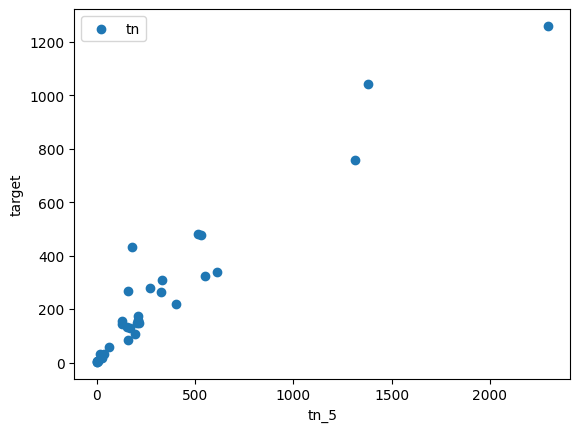

In [ ]:
# plot regression
import matplotlib.pyplot as plt
# tn_1 and tn
plt.scatter(X_train["tn_2"], y_train, label="tn")

plt.xlabel("tn_5")
plt.ylabel("target")
plt.legend()
plt.show()

In [ ]:

def test_eval(df_grouped, product_ids, train_features, reg):
    eval_df = df_grouped[
        (df_grouped["fecha"] == "2019-10") & (df_grouped["product_id"].isin(product_ids))
    ].copy()
    X_eval = eval_df[train_features].dropna()
    y_eval = eval_df.loc[X_eval.index, "target"]
    y_pred = reg.predict(X_eval)
    total_error = (y_eval - y_pred).abs().sum() / y_eval.sum()
    print(f"Total error: {total_error:.4f}")
    return total_error
test_eval(df_grouped, product_ids, train_features, reg)

Total error: 0.2657


np.float32(0.26567942)

In [ ]:
# test df 2019-12 para product_ids
test_df = df_grouped[
    (df_grouped["fecha"] == "2019-12") & (df_grouped["product_id"].isin(product_ids))
].copy()


# Uso como X_test las rows donde todas las features son distinto de NaN, ademas me guardo sus product_ids
X_test = test_df[train_features + ["product_id"]].dropna()

# hago las predicciones en X_test ocn el regresor lineal, para los product_ids que tienen nan uso la columna tn_rolling_mean_12 como prediccion
y_pred = reg.predict(X_test[train_features])
y_pred = pd.DataFrame(
    {
        "product_id": X_test["product_id"],
        "prediction": y_pred,
    }
)
y_pred

# para los restantes uso la media
product_ids_restantes = (
    test_df[~test_df["product_id"].isin(y_pred["product_id"])]["product_id"].unique()
)
y_pred_restantes = pd.DataFrame(
    {
        "product_id": product_ids_restantes,
        "prediction": test_df[test_df["product_id"].isin(product_ids_restantes)][
            "tn_rolling_mean_12"
        ],
    } )

y_pred_restantes

submission = pd.concat([y_pred, y_pred_restantes], ignore_index=True)
submission = submission.merge(test_df[["product_id", "tn"]], on="product_id", how="left")
submission["tn"] = submission["tn"] + submission["prediction"]
submission = submission[["product_id", "tn"]]
submission = submission.clip(lower=0)
submission.to_csv(DATA_FOLDER + "submission_regresion.csv", index=False)

submission

,product_id,tn
0,20001,1621.883087
1,20002,1144.172058
2,20003,871.145657
3,20004,613.018200
4,20005,671.989128
...,...,...
775,21252,0.052454
776,21265,0.053863
777,21266,0.055003
778,21267,0.000000


In [ ]:
y_pred_restantes

,product_id,prediction
30626,20032,27.979929
30712,20127,52.507985
30753,20174,2.853298
30786,20210,17.000763
30789,20213,4.030598
...,...,...
31509,21252,-0.033146
31517,21265,0.003793
31518,21266,0.003793
31519,21267,-0.022232


In [ ]:
#submission es un dataframe con 2 columnas product_id y tn
# concateno las predicciones
submission = pd.concat([y_pred, y_pred_restantes], ignore_index=True)
submission = submission.rename(columns={"prediction": "tn"})
submission


,product_id,prediction
30700,20032,590.333650
30788,20127,208.437448
30829,20174,114.811757
30862,20210,82.177315
30865,20213,78.120207
...,...,...
31630,21252,0.178011
31639,21265,0.089541
31640,21266,0.094659
31641,21267,0.092835


In [ ]:
train_df = df_grouped[
    (df_grouped["fecha"] <= "2019-08")]
test_df = df_grouped[
    (df_grouped["fecha"] == "2019-10") & (df_grouped["product_id"].isin(product_ids))]

In [ ]:
train_df

,fecha,product_id,tn,target,tn_rolling_mean_12
0,2017-01,20001,934.772217,1303.357666,934.772217
1,2017-01,20002,550.157043,834.735229,550.157043
2,2017-01,20003,1063.458374,917.165466,1063.458374
3,2017-01,20004,555.916138,489.913269,555.916138
4,2017-01,20005,494.270111,563.899597,494.270111
...,...,...,...,...,...
27786,2019-08,21267,0.040540,0.096760,0.126180
27787,2019-08,21269,0.117710,0.037840,0.122618
27788,2019-08,21270,0.812780,NaN,0.812780
27789,2019-08,21271,0.017840,0.024530,0.009414


In [ ]:
# calculo el std y el tn de cada producto
group_stats = train_df.groupby("product_id").agg(
    {
        "tn": ["std", "mean"],
    }
)
group_stats

tn             
                   std         mean
product_id                         
20001       310.877625  1381.775757
20002       255.975647   961.145142
20003       307.684814   878.569397
20004       225.978851   655.170105
20005       218.206009   628.585999
...                ...          ...
21295              NaN     0.006990
21296              NaN     0.006510
21297              NaN     0.005790
21298              NaN     0.005730
21299              NaN     0.005460

[1181 rows x 2 columns]

In [ ]:
# hago otro enfoque con lightgbm y usando linear_tree

# ttest df es hasta 2019-10, y train df es hasta 2019-08 inclusive
from lightgbm import LGBMRegressor
# import StandarScaler
train_df = df_grouped[
    (df_grouped["fecha"] <= "2019-08")]
test_df = df_grouped[
    (df_grouped["fecha"] == "2019-10") & (df_grouped["product_id"].isin(product_ids))]

train_features = ["tn"] + [f"tn_{i}" for i in range(1, 12)]

group_stats = train_df.groupby("product_id").agg(
    {
        "tn": ["std", "mean"],
    }
)
# renombro las columnas de group_stats
group_stats.columns = ["tn_std", "tn_mean"]

for feature in train_features + ["target"]:
    # hago un merge con group_stats para agregar las columnas de std y mean
    train_df = train_df.merge(
        group_stats,
        on="product_id",
        how="left",
        suffixes=("", f"_{feature}"),
    )
    # renombro las columnas
    train_df = train_df.rename(
        columns={
            f"tn_std": f"{feature}_std",
            f"tn_mean": f"{feature}_mean",
        }
    )
    train_df[feature] = (train_df[feature] - train_df[f"{feature}_mean"]) / train_df[f"{feature}_std"]
    train_df = train_df.drop(columns=[f"{feature}_std", f"{feature}_mean"])

X_train = train_df[train_features + ["product_id"]]
y_train = train_df["target"]


In [ ]:
X_train

,tn,tn_1,tn_2,tn_3,tn_4,tn_5,tn_6,tn_7,tn_8,tn_9,tn_10,tn_11,product_id
0,-1.437876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20001
1,-1.605575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20002
2,0.600904,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20003
3,-0.439218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20004
4,-0.615546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20005
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27786,-1.001228,-0.603963,-0.787514,1.383410,-0.038230,1.047524,NaN,NaN,NaN,NaN,NaN,NaN,21267
27787,-0.092685,-0.727727,-1.323115,1.137933,-0.171995,1.177588,NaN,NaN,NaN,NaN,NaN,NaN,21269
27788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21270
27789,-0.360370,-0.611557,-1.005936,0.875317,-1.131288,-0.825621,-0.718589,-0.861298,-0.898422,-1.220481,-1.220481,-1.220481,21271


In [ ]:


#
regressor = LGBMRegressor(
    extra_trees=True,
    n_estimators=100,
    num_leaves=64,
    linear_tree=True,  # Use linear trees
)
regressor.fit(X_train[train_features], y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,001543 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 27791, number of used features: 12
[LightGBM] [Info] Start training from score -0,035467


LGBMRegressor(extra_trees=True, linear_tree=True, num_leaves=64)

In [ ]:
preds = regressor.predict(test_df[train_features])
preds

array([ 5.30959429e+04,  4.32927282e+04,  2.98415625e+04,  1.85089023e+04,
        1.32535030e+04,  2.09945802e+04,  1.42999576e+04,  1.61266588e+04,
        1.70837010e+04,  1.25160818e+04,  1.05020564e+04,  1.23730220e+04,
        1.39290966e+04,  1.40882609e+04,  1.26652858e+04,  8.95503108e+03,
        1.11160953e+04,  1.35977633e+04,  1.37919509e+04,  8.69988937e+03,
        7.86098222e+03,  7.95972325e+03,  9.44530350e+03,  6.56884189e+03,
        5.99295399e+03,  7.17430402e+03,  8.39528217e+03,  8.03223107e+03,
        8.24414297e+03,  5.64665683e+03,  6.63607901e+03, -1.35431904e+03,
        5.34582934e+03,  5.84917892e+03,  4.46840800e+03,  5.71516495e+03,
        4.58611686e+03,  4.66047038e+03,  5.94417271e+03,  5.01705345e+03,
        4.82227771e+03,  5.89418610e+03,  4.85329556e+03,  5.58314910e+03,
        7.26445128e+03,  2.65992410e+03,  5.87532607e+03,  3.78798272e+03,
        4.84078600e+03,  3.02473657e+03,  2.93454436e+03,  3.47380092e+03,
        4.44238012e+03,  

In [ ]:
import numpy as np
preds = regressor.predict(test_df[train_features])

# hago el scaling inverso usando group_stats

#preds = target_scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
preds = pd.DataFrame(
    {
        "product_id": test_df["product_id"],
        "prediction": preds,
        "real": test_df["target"],
    }
)
preds = preds.merge(group_stats, on="product_id", how="left")
preds["prediction"] = preds["prediction"] * preds["tn_std"] + preds["tn_mean"]

print("Total error", np.sum(np.abs(preds["prediction"] - preds["real"]))/np.sum(preds["real"]))
preds

Total error 3792.8271640729436


,product_id,prediction,real,tn_std,tn_mean
0,20001,1.650772e+07,1504.688599,310.877625,1381.775757
1,20002,1.108285e+07,1087.308594,255.975647,961.145142
2,20003,9.182674e+06,892.501282,307.684814,878.569397
3,20004,4.183276e+06,637.900024,225.978851,655.170105
4,20005,2.892623e+06,593.244446,218.206009,628.585999
...,...,...,...,...,...
775,21263,1.595093e-01,0.012700,0.173606,0.115139
776,21265,1.566947e-01,0.050070,0.138965,0.108843
777,21266,1.579634e-01,0.051210,0.135148,0.113583
778,21267,1.524922e-01,0.015690,0.085535,0.126180
